<a href="https://colab.research.google.com/github/sdivyadarshini29-coder/DATA-SCIENCE-INTERNSHIP/blob/main/knn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

In [4]:
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

In [6]:
wine=load_wine()

In [9]:
df=pd.DataFrame(wine.data,columns=wine.feature_names)

In [15]:
df['target']=wine.target

In [10]:
df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 13 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64
dtypes: fl

In [12]:
print("shape:",df.shape)

shape: (178, 13)


In [13]:
print("describe:",df.describe())

describe:           alcohol  malic_acid         ash  alcalinity_of_ash   magnesium  \
count  178.000000  178.000000  178.000000         178.000000  178.000000   
mean    13.000618    2.336348    2.366517          19.494944   99.741573   
std      0.811827    1.117146    0.274344           3.339564   14.282484   
min     11.030000    0.740000    1.360000          10.600000   70.000000   
25%     12.362500    1.602500    2.210000          17.200000   88.000000   
50%     13.050000    1.865000    2.360000          19.500000   98.000000   
75%     13.677500    3.082500    2.557500          21.500000  107.000000   
max     14.830000    5.800000    3.230000          30.000000  162.000000   

       total_phenols  flavanoids  nonflavanoid_phenols  proanthocyanins  \
count     178.000000  178.000000            178.000000       178.000000   
mean        2.295112    2.029270              0.361854         1.590899   
std         0.625851    0.998859              0.124453         0.572359   
min  

In [14]:
df.isnull().sum()

,0
alcohol,0
malic_acid,0
ash,0
alcalinity_of_ash,0
magnesium,0
total_phenols,0
flavanoids,0
nonflavanoid_phenols,0
proanthocyanins,0
color_intensity,0


/tmp/ipykernel_7955/3108532664.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='target',data=df,palette='Set2')


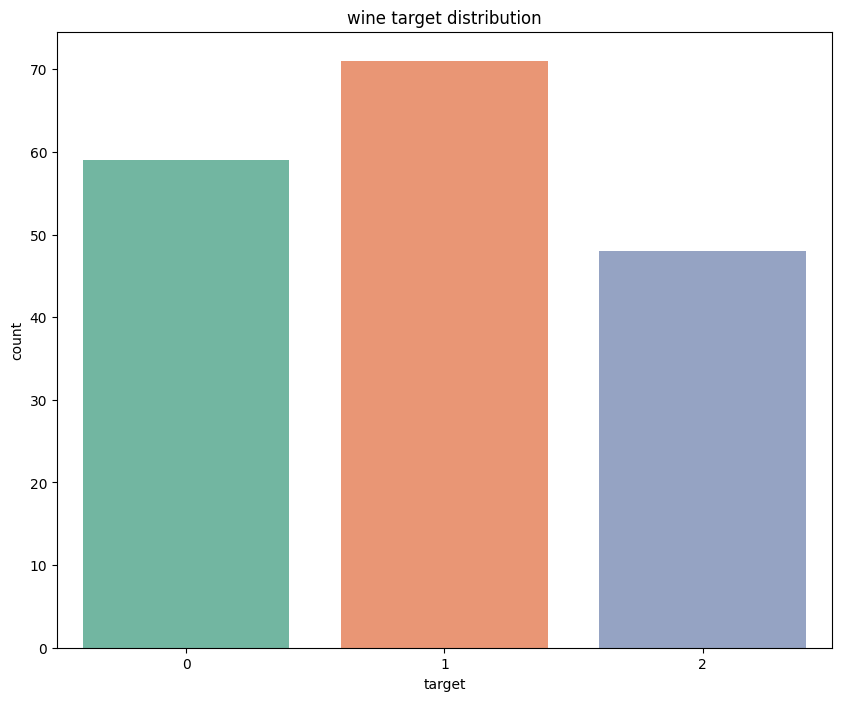

In [17]:
plt.figure(figsize=(10,8))
sns.countplot(x='target',data=df,palette='Set2')
plt.title('wine target distribution')
plt.xlabel('target')
plt.ylabel('count')
plt.show()

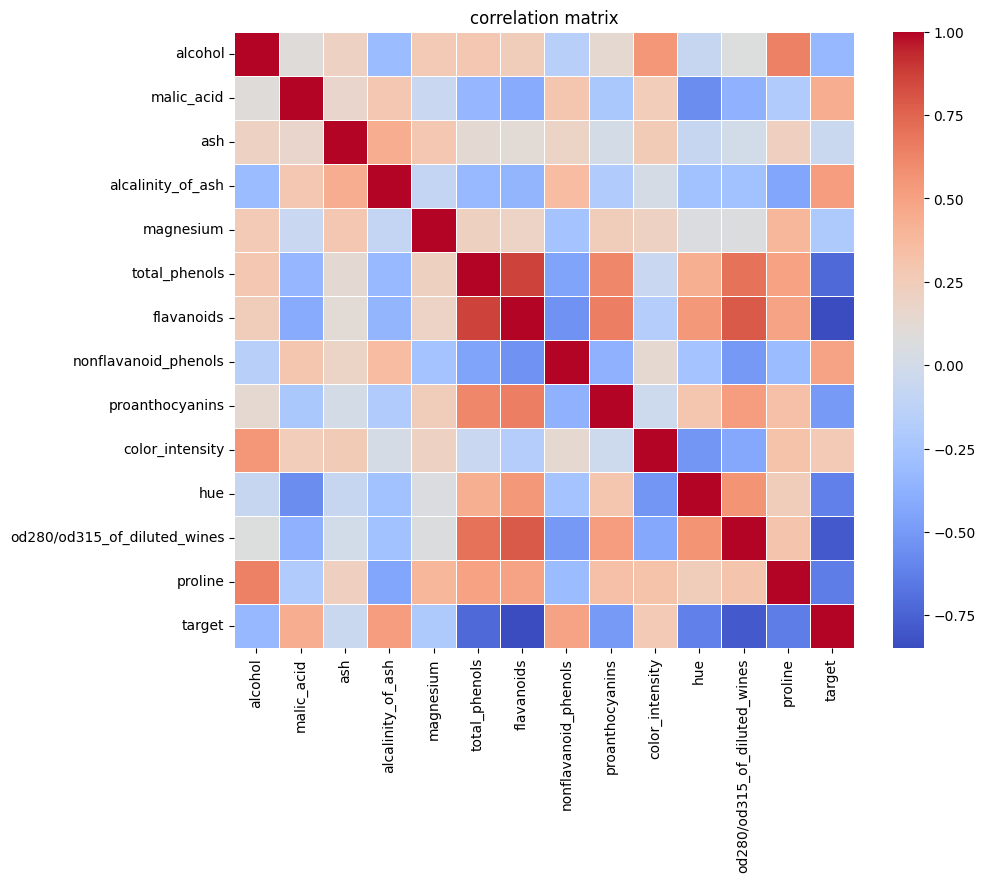

In [18]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(),cmap='coolwarm',linewidth=0.5)
plt.title('correlation matrix')
plt.show()



/tmp/ipykernel_7955/1555681291.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='target',y='alcohol',data=df,palette='Set2')


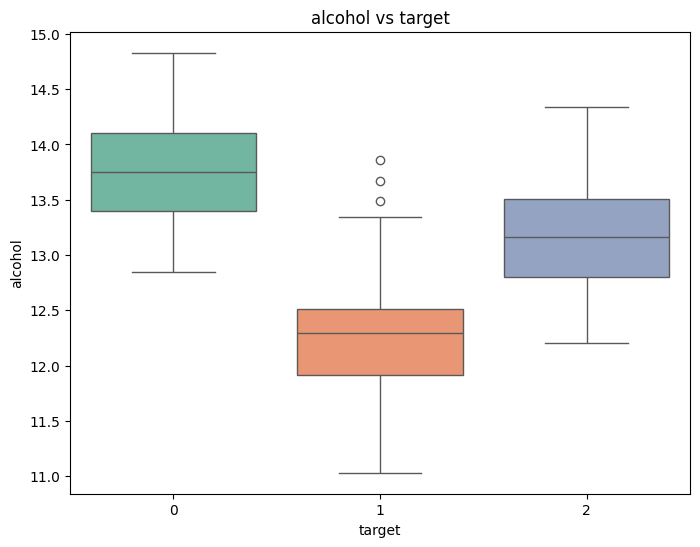

In [20]:
plt.figure(figsize=(8,6))
sns.boxplot(x='target',y='alcohol',data=df,palette='Set2')
plt.title('alcohol vs target')
plt.xlabel('target')
plt.ylabel('alcohol')
plt.show()

/tmp/ipykernel_7955/3153544303.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='target',y='color_intensity',data=df,palette='Set2')


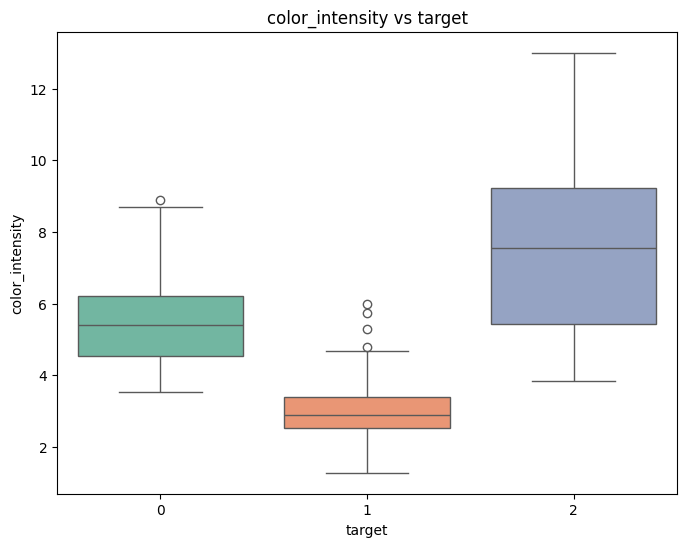

In [21]:
plt.figure(figsize=(8,6))
sns.boxplot(x='target',y='color_intensity',data=df,palette='Set2')
plt.title('color_intensity vs target')
plt.xlabel('target')
plt.ylabel('color_intensity')
plt.show()

In [23]:
X=df.drop('target',axis=1)
y=df['target']

In [24]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [25]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Accuracy: 0.9722222222222222

Confusion Matrix:
[[12  0  0]
 [ 0 13  1]
 [ 0  0 10]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       1.00      0.93      0.96        14
           2       0.91      1.00      0.95        10

    accuracy                           0.97        36
   macro avg       0.97      0.98      0.97        36
weighted avg       0.97      0.97      0.97        36



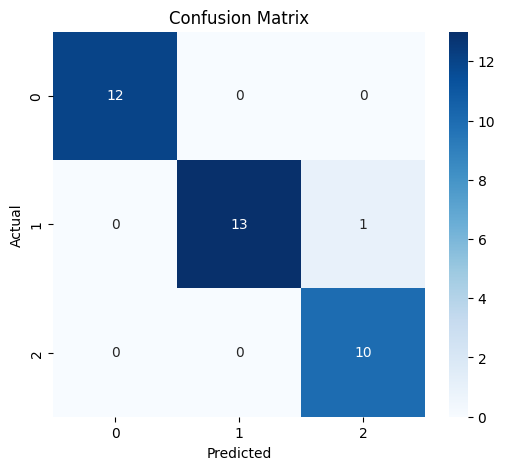

Predicted Wine Class: 0
Actual Wine Class   : 0
Predicted Class Name: class_0
Actual Class Name   : class_0


In [27]:
model = KNeighborsClassifier(n_neighbors=5)
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)
print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

plt.figure(figsize=(6, 5))
sns.heatmap(
    confusion_matrix(y_test, y_pred),
    annot=True,
    fmt='d',
    cmap='Blues'
)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


new_wine = pd.DataFrame(
    [wine.data[0]],
    columns=wine.feature_names
)


new_wine_scaled = scaler.transform(new_wine)


predicted_class = model.predict(new_wine_scaled)

print("Predicted Wine Class:", predicted_class[0])
print("Actual Wine Class   :", wine.target[0])


print("Predicted Class Name:", wine.target_names[predicted_class[0]])
print("Actual Class Name   :", wine.target_names[wine.target[0]])

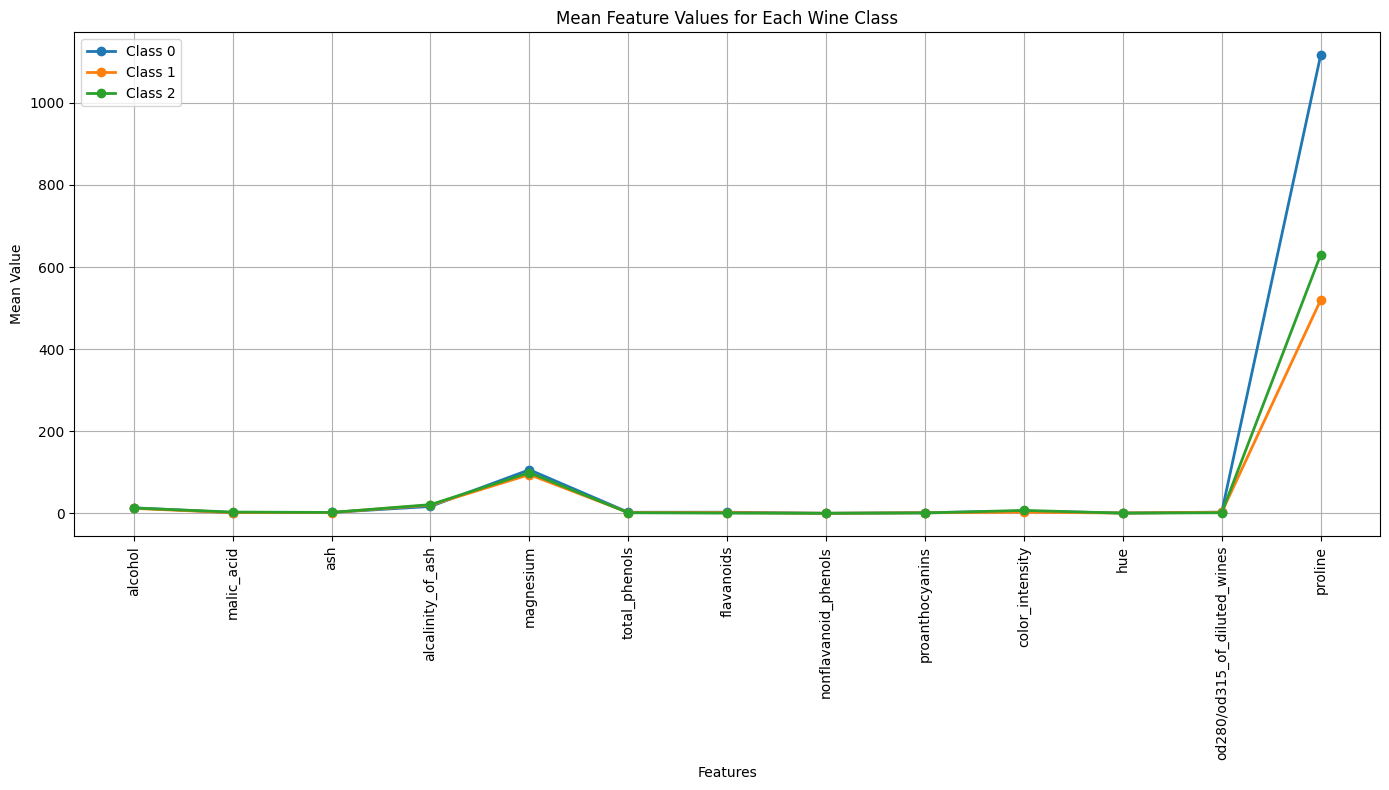

In [28]:

class_means = df.groupby('target').mean().T


plt.figure(figsize=(14, 8))

for col in class_means.columns:
    plt.plot(
        class_means.index,
        class_means[col],
        marker='o',
        linewidth=2,
        label=f'Class {col}'
    )

plt.title("Mean Feature Values for Each Wine Class")
plt.xlabel("Features")
plt.ylabel("Mean Value")
plt.xticks(rotation=90)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()